# Create_Sign

In [ ]:
###############

# Collage_Labelling

In [42]:
import sys
sys.path.append("CollageLabelling")

import importlib
import CollageLabelling
importlib.reload(CollageLabelling)

from CollageLabelling import Image_Merger_Labelling

In [24]:
img_lb_path = "./Resource/Bien_1.jpg"
img_bg_path = "./Resource/BG_1.jpg"
auto_tool = Image_Merger_Labelling(img_lb_path, img_bg_path, "Hinh_tron")

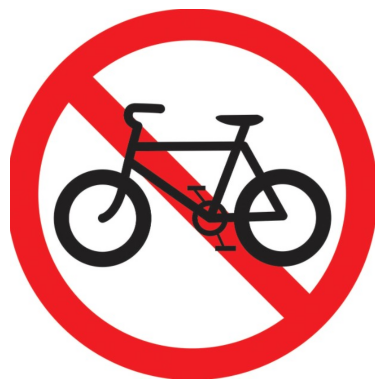

In [25]:
auto_tool.Show_lb()

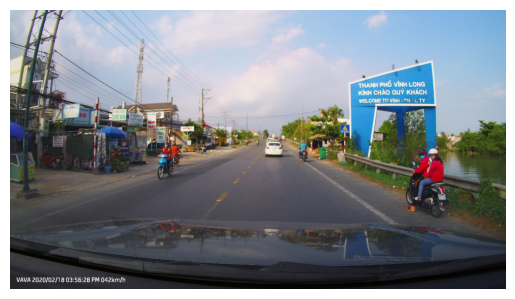

In [26]:
auto_tool.Show_bg()

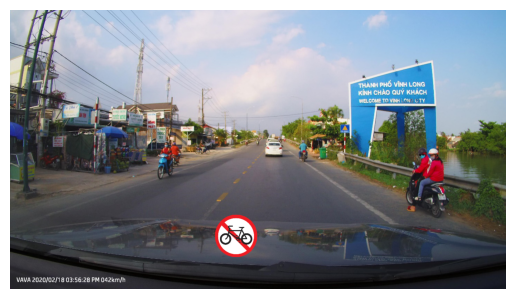

In [ ]:
ratio = 0.2
auto_tool.ShowMerge(0.2, 0.2, 590, 590)

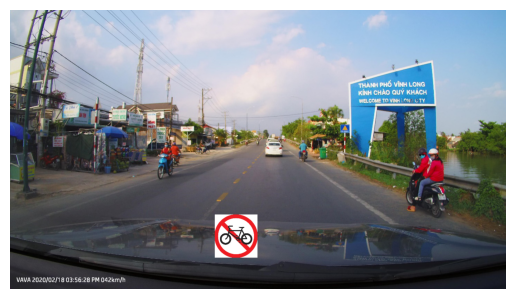

In [30]:
auto_tool = Image_Merger_Labelling(img_lb_path, img_bg_path)
ratio = 0.2
auto_tool.ShowMerge(0.2, 0.2, 590, 590)

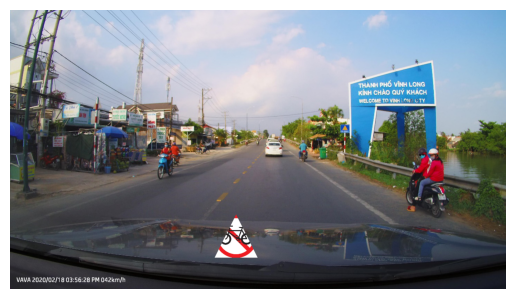

In [43]:
auto_tool = Image_Merger_Labelling(img_lb_path, img_bg_path, "Hinh_tam_giac")
ratio = 0.2
auto_tool.ShowMerge(0.2, 0.2, 590, 590)

In [49]:
auto_tool.Auto_Labelling(ratio, ratio, 590, 590, "./", "test_1", '0')

0

In [ ]:
import cv2

# Đọc ảnh
image_path = img_bg_path  # Đường dẫn đến ảnh
image = cv2.imread(image_path)
H, W, _ = image.shape  # Lấy kích thước ảnh

# Đọc file nhãn YOLO
label_path = "./test_1.txt"  # File YOLO label
with open(label_path, "r") as file:
    lines = file.readlines()

# Duyệt qua từng dòng trong file nhãn
for line in lines:
    data = line.strip().split()
    class_id = int(data[0])  # Lớp của đối tượng
    x_center, y_center, width, height = map(float, data[1:])

    # Chuyển đổi tọa độ YOLO sang pixel
    xmin = int((x_center - width / 2) * W)
    ymin = int((y_center - height / 2) * H)
    xmax = int((x_center + width / 2) * W)
    ymax = int((y_center + height / 2) * H)

    # Vẽ bounding box lên ảnh
    color = (0, 255, 0)  # Màu xanh lá
    thickness = 2
    cv2.rectangle(image, (xmin, ymin), (xmax, ymax), color, thickness)

    # Hiển thị nhãn class_id trên bounding box
    label = f"Class {class_id}"
    cv2.putText(image, label, (xmin, ymin - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

# Hiển thị ảnh
# cv2.imshow("YOLO Bounding Box", image)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

# Lưu ảnh có bounding box
cv2.imwrite("output.jpg", image)


True